In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("16-diabetes.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df["Insulin"].value_counts()

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
73       1
171      1
255      1
52       1
112      1
Name: count, Length: 186, dtype: int64

In [9]:
df["BloodPressure"].value_counts()

BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
52     11
54     11
75      8
92      8
65      7
85      6
94      6
48      5
96      4
44      4
100     3
106     3
98      3
110     3
55      2
108     2
104     2
46      2
30      2
122     1
95      1
102     1
61      1
24      1
38      1
40      1
114     1
Name: count, dtype: int64

In [10]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [11]:
columns_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

In [12]:
for col in columns_to_check:
    zero_counts = (df[col] == 0).sum()
    print(zero_counts)
    zero_percentage = 100 * zero_counts/len(df)
    print(f"{col}: {zero_counts} % {zero_percentage:2f}")

5
Glucose: 5 % 0.651042
35
BloodPressure: 35 % 4.557292
227
SkinThickness: 227 % 29.557292
374
Insulin: 374 % 48.697917
11
BMI: 11 % 1.432292


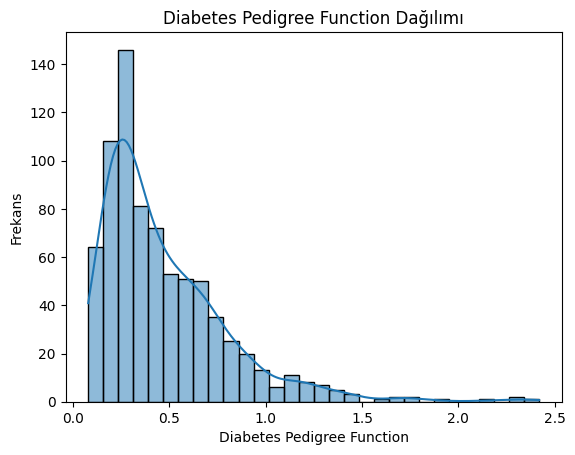

In [13]:
sns.histplot(df["DiabetesPedigreeFunction"], bins=30, kde=True)
plt.title("Diabetes Pedigree Function Dağılımı")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Frekans")
plt.show()

In [14]:
X=df.drop("Outcome", axis = 1)
y=df["Outcome"]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=15)

In [16]:
columns_to_fill = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

In [17]:
medians = {}
for col in columns_to_fill:
    median_value = X_train[X_train[col] !=0][col].median()
    medians[col] = median_value
    X_train[col] = X_train[col].replace(0, median_value)

for col in columns_to_fill:
    X_test[col] = X_test[col].replace(0, medians[col])

In [18]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [27]:
from sklearn.model_selection import GridSearchCV

In [20]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [21]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154

0.7532467532467533
[[87 21]
 [17 29]]


In [22]:
#hyperparameter tuning

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [24]:
adaboost_param = {
    "n_estimators": [50, 70, 100, 120, 150, 200],
    "learning_rate": [0.001, 0.01, 0.1, 1, 10]
}

In [28]:
grid = GridSearchCV(estimator = AdaBoostClassifier(), param_grid = adaboost_param, cv=5, verbose = 1, n_jobs = -1)

In [29]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.001, 0.01, ...], 'n_estimators': [50, 70, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [30]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 150}

In [31]:
ada = AdaBoostClassifier(learning_rate=1, n_estimators=150)

In [32]:
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.59      0.65      0.62        46

    accuracy                           0.76       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.77      0.76      0.76       154

0.7597402597402597
[[87 21]
 [16 30]]


In [33]:
classification_models = {
    "LogisticRegression": (LogisticRegression(), {"C": [0.1, 1, 10]}),
    "RandomForest": (RandomForestClassifier(), {"n_estimators": [50, 100, 200]}),
    "AdaBoost": (AdaBoostClassifier(), {"n_estimators": [50, 100], "learning_rate": [0.1, 1.0]}),
    "SVC": (SVC(), {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]})
}

for name, (model, params) in classification_models.items():
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)
    
    y_pred = grid.predict(X_test)
    print(f"\n--- {name} ---")
    print(f"En İyi Parametreler: {grid.best_params_}")
    print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred):.4f}")


--- LogisticRegression ---
En İyi Parametreler: {'C': 1}
Doğruluk (Accuracy): 0.7532

--- RandomForest ---
En İyi Parametreler: {'n_estimators': 50}
Doğruluk (Accuracy): 0.7273

--- AdaBoost ---
En İyi Parametreler: {'learning_rate': 1.0, 'n_estimators': 100}
Doğruluk (Accuracy): 0.7727

--- SVC ---
En İyi Parametreler: {'C': 1, 'kernel': 'linear'}
Doğruluk (Accuracy): 0.7468


In [34]:
grid.best_params_

{'C': 1, 'kernel': 'linear'}

In [35]:
scaler = StandardScaler()

In [36]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
X_train_scaled

array([[-0.26817973,  0.94957417,  0.27868518, ..., -1.66947829,
        -0.80106331,  0.31836832],
       [-1.15505057,  0.14823841,  0.93681095, ..., -0.25493911,
         0.15248236, -0.79571145],
       [ 0.61869112, -0.25242946, -0.05037771, ..., -0.02161306,
        -0.8558998 , -0.62431456],
       ...,
       [-0.56380334,  1.18329709,  0.11415374, ...,  1.01377129,
        -1.02345575, -0.28152078],
       [-1.15505057,  0.04807144, -0.05037771, ...,  0.56170206,
        -0.64569325,  1.60384499],
       [-0.85942696,  0.44873932, -1.5311607 , ..., -0.83825424,
         0.66124315,  2.46082943]], shape=(614, 8))

In [38]:
for name, (model, params) in classification_models.items():
    grid = GridSearchCV(model, params, cv=5)
    
    grid.fit(X_train_scaled, y_train)
    
    y_pred = grid.predict(X_test_scaled)
    
    print(f"\n--- {name} (Scaled Veri) ---")
    print(f"En İyi Parametreler: {grid.best_params_}")
    print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred):.4f}")


--- LogisticRegression (Scaled Veri) ---
En İyi Parametreler: {'C': 1}
Doğruluk (Accuracy): 0.7532

--- RandomForest (Scaled Veri) ---
En İyi Parametreler: {'n_estimators': 100}
Doğruluk (Accuracy): 0.7208

--- AdaBoost (Scaled Veri) ---
En İyi Parametreler: {'learning_rate': 1.0, 'n_estimators': 100}
Doğruluk (Accuracy): 0.7727

--- SVC (Scaled Veri) ---
En İyi Parametreler: {'C': 1, 'kernel': 'linear'}
Doğruluk (Accuracy): 0.7468


In [39]:
from xgboost import XGBClassifier

classification_models = {
    "AdaBoost": (AdaBoostClassifier(), {"n_estimators": [100, 200], "learning_rate": [0.1, 0.5, 1.0]}),
    "XGBoost": (XGBClassifier(use_label_encoder=False, eval_metric='logloss'), 
                {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]}),
    "RandomForest": (RandomForestClassifier(), {"n_estimators": [100, 200], "max_depth": [None, 10, 20]})
}

In [40]:
print((df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] == 0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [41]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

df.fillna(df.median(), inplace=True)

In [42]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [43]:
%pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [44]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

advanced_models = {
    "XGBoost": (XGBClassifier(eval_metric='logloss'), 
                {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]}),
    "LightGBM": (LGBMClassifier(verbose=-1), 
                 {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1]}),
    "AdaBoost": (AdaBoostClassifier(), 
                 {"n_estimators": [100, 200], "learning_rate": [0.1, 0.5, 1.0]})
}

In [45]:
for name, (model, params) in advanced_models.items():
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid.fit(X_train_scaled, y_train)
    
    y_pred = grid.predict(X_test_scaled)
    print(f"\n--- {name} (Temizlenmiş & Scaled) ---")
    print(f"En İyi Parametreler: {grid.best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


--- XGBoost (Temizlenmiş & Scaled) ---
En İyi Parametreler: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Accuracy: 0.7273


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-p


--- LightGBM (Temizlenmiş & Scaled) ---
En İyi Parametreler: {'learning_rate': 0.01, 'n_estimators': 200}
Accuracy: 0.7662

--- AdaBoost (Temizlenmiş & Scaled) ---
En İyi Parametreler: {'learning_rate': 1.0, 'n_estimators': 100}
Accuracy: 0.7727


In [46]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)

In [47]:
from sklearn.ensemble import VotingClassifier

voter = VotingClassifier(estimators=[
    ('ada', AdaBoostClassifier(n_estimators=100, learning_rate=1.0)),
    ('lgbm', LGBMClassifier(n_estimators=200, learning_rate=0.01, verbose=-1)),
    ('lr', LogisticRegression(C=1))
], voting='hard')

voter.fit(X_train_scaled, y_train)
print(f"Voting Classifier Skoru: {accuracy_score(y_test, voter.predict(X_test_scaled)):.4f}")

Voting Classifier Skoru: 0.7727


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [48]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [49]:
#BMI sınıflandırması Zayıf", 18.5-25 "Normal", 25-30 "Kilolu", 30+ "Obez"
# Glikoz seviyesi 140 mg/dL altı "Normal", 140-199 "Pre-diyabet", 200+ "Diyabetik" olarak işaretle.
# yaş ilerledikçe diyabet riski artar Age * BMI
# BMI ile glikoz seviyesi arasında bağ var mı bak Glucose * BMI
# glikoz düşük ama insülin yüksekse vücudun şekeri dengelemek istediğini gösterir Insulin / Glucose
# cilt kalınlığı ile yağ oranı arasındaki ilişki

In [50]:
df["Age_BMI"] = df["Age"] * df["BMI"]

In [52]:
df['Insulin/Glucose'] = df['Insulin'] / (df['Glucose'] + 1)

In [53]:
df['BMI_Cat'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3])

In [54]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_BMI,Insulin/Glucose,BMI_Cat
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1680.0,0.838926,3
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,824.6,1.453488,2
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,745.6,0.679348,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,1.044444,2
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,1.217391,3


In [55]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=15)

In [57]:
param = {

    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [1,2,3,4,5,15,None],
    "max_features": ["sqrt", "log2", None],
    "ccp_alpha": [0.0, 0.1, 1.0, 10.0]
                    

}

In [66]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier

In [60]:
grid = GridSearchCV(estimator = DecisionTreeClassifier(), param_grid = param, cv=5, scoring="accuracy")

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [65]:
for name, (model, params) in advanced_models.items():
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid.fit(X_train_scaled, y_train)
    
    y_pred = grid.predict(X_test_scaled)
    print(f"\n--- {name} (Temizlenmiş & Scaled) ---")
    print(f"En İyi Parametreler: {grid.best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


--- XGBoost (Temizlenmiş & Scaled) ---
En İyi Parametreler: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Accuracy: 0.7532


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.14/site-p


--- LightGBM (Temizlenmiş & Scaled) ---
En İyi Parametreler: {'learning_rate': 0.01, 'n_estimators': 100}
Accuracy: 0.7208

--- AdaBoost (Temizlenmiş & Scaled) ---
En İyi Parametreler: {'learning_rate': 0.5, 'n_estimators': 200}
Accuracy: 0.7597


In [67]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm="auto", weights="uniform")

In [69]:
classifier.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [70]:
y_pred = classifier.predict(X_test_scaled)

In [72]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[82 20]
 [26 26]]
accuracy score:  0.7012987012987013
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       102
           1       0.57      0.50      0.53        52

    accuracy                           0.70       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.69      0.70      0.70       154



In [73]:
print(df.corr()['Outcome'].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.492782
Age_BMI                     0.362990
BMI                         0.312038
BMI_Cat                     0.307594
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Insulin/Glucose             0.015696
Name: Outcome, dtype: float64


In [76]:
df.drop("BMI", axis=1, inplace=True)

In [77]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age,Outcome,Age_BMI,Insulin/Glucose,BMI_Cat
0,6,148.0,72.0,35.0,125.0,0.627,50,1,1680.0,0.838926,3
1,1,85.0,66.0,29.0,125.0,0.351,31,0,824.6,1.453488,2
2,8,183.0,64.0,29.0,125.0,0.672,32,1,745.6,0.679348,1
3,1,89.0,66.0,23.0,94.0,0.167,21,0,590.1,1.044444,2
4,0,137.0,40.0,35.0,168.0,2.288,33,1,1422.3,1.217391,3


In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [79]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
classifier.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [81]:
y_pred = classifier.predict(X_test_scaled)

In [82]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[104  27]
 [ 25  36]]
accuracy score:  0.7291666666666666
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       131
           1       0.57      0.59      0.58        61

    accuracy                           0.73       192
   macro avg       0.69      0.69      0.69       192
weighted avg       0.73      0.73      0.73       192



In [83]:
strong_features = ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI_Cat', 'Age_BMI', 'Age', 'Outcome']
df_filtered = df[strong_features]

In [84]:
X = df_filtered.drop("Outcome", axis=1)
y = df_filtered["Outcome"]

In [85]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

In [95]:
models = {
    "LogisticReg": (LogisticRegression(), {"C": [0.01, 0.1, 1, 10]}),
    "AdaBoost": (AdaBoostClassifier(), {
        "n_estimators": [50, 100, 150, 200], 
        "learning_rate": [0.05, 0.1, 0.5, 1], 
        "random_state": [15]  # Köşeli parantez içine aldık!
    }),
    "RandomForest": (RandomForestClassifier(), {
        "n_estimators": [1, 10, 50, 100, 200], 
        "max_depth": [3, 5, 7, 8, 10, None],
        "random_state": [15]  # Burada da varsa liste içine almalısın
    }),
    "SVC": (SVC(), {"C": [0.1, 1, 10], "kernel": ['linear', 'rbf']})
}

In [96]:
for name, (model_obj, params) in models.items():
    grid = GridSearchCV(estimator=model_obj, param_grid=params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    print(f"En İyi Ayarlar: {grid.best_params_}")
    print(f"Accuracy (Doğruluk): {accuracy_score(y_test, y_pred):.4f}")
    print("Karmaşıklık Matrisi (Confusion Matrix):")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 40)

En İyi Ayarlar: {'C': 1}
Accuracy (Doğruluk): 0.7552
Karmaşıklık Matrisi (Confusion Matrix):
[[109  20]
 [ 27  36]]
----------------------------------------
En İyi Ayarlar: {'learning_rate': 0.5, 'n_estimators': 100, 'random_state': 15}
Accuracy (Doğruluk): 0.7396
Karmaşıklık Matrisi (Confusion Matrix):
[[107  22]
 [ 28  35]]
----------------------------------------
En İyi Ayarlar: {'max_depth': 7, 'n_estimators': 10, 'random_state': 15}
Accuracy (Doğruluk): 0.7500
Karmaşıklık Matrisi (Confusion Matrix):
[[107  22]
 [ 26  37]]
----------------------------------------
En İyi Ayarlar: {'C': 0.1, 'kernel': 'linear'}
Accuracy (Doğruluk): 0.7604
Karmaşıklık Matrisi (Confusion Matrix):
[[112  17]
 [ 29  34]]
----------------------------------------
